# Detecting Feature Interactions in LIME for Image Classification
## MTP-2: Beyond Independent Attribution

**Aman Tiwari** (24CS60R35)  
Department of Computer Science and Engineering, IIT Kharagpur  
Supervisor: Prof. Palash Dey

---

This notebook empirically investigates whether LIME's independence assumption holds for image classification using ResNet-50.

For every pair of superpixels $(i, j)$, we measure the **pairwise interaction effect**:

$$I(i,j) = \Delta_{ij} - \Delta_i - \Delta_j$$

where $\Delta_i$ is the confidence drop when hiding superpixel $i$ alone, and $\Delta_{ij}$ is the joint drop when hiding both together.

If LIME's independence assumption holds, we would expect $I(i,j) \approx 0$ for all pairs. We show that this is frequently violated.

In [2]:
!pip install -q lime scikit-image

In [3]:
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from skimage.segmentation import quickshift, mark_boundaries
from lime import lime_image
from itertools import combinations
import matplotlib
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from tqdm.notebook import tqdm
import time

%matplotlib inline
%config InlineBackend.figure_formats = ['png']
%config InlineBackend.print_figure_kwargs = {'dpi': 50}
plt.rcParams['figure.dpi'] = 50
plt.rcParams['savefig.dpi'] = 50

In [4]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model loaded on: {device}")

resp = requests.get(
    "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
)
labels = resp.json()
print(f"Loaded {len(labels)} class labels")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 119MB/s]


Model loaded on: cuda
Loaded 1000 class labels


In [5]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


def predict_probs(img_np_array):
    batch = torch.stack([
        preprocess(Image.fromarray(img.astype(np.uint8)))
        for img in img_np_array
    ])
    batch = batch.to(device)
    with torch.no_grad():
        logits = model(batch)
        probs = torch.nn.functional.softmax(logits, dim=1)
    return probs.cpu().numpy()


def get_confidence(img_np, class_idx):
    probs = predict_probs([img_np])
    return float(probs[0, class_idx])


def hide_superpixels(img_np, segments, hide_ids):
    perturbed = img_np.copy()
    fill = img_np.mean(axis=(0, 1))
    mask = np.isin(segments, list(hide_ids))
    perturbed[mask] = fill
    return perturbed

In [6]:
import urllib.request
import ssl

ANIMAL_IMAGES = {
    "tabby_cat": [
        "https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
    ],
    "golden_retriever": [
        "https://upload.wikimedia.org/wikipedia/commons/a/ab/Golden_Retriever_Hund_Dog.JPG",
        "https://upload.wikimedia.org/wikipedia/commons/9/93/Golden_Retriever_Carlos_%2810581910556%29.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/b/bd/Golden_Retriever_Dukedestiny01_dread08.jpg",
    ],
    "german_shepherd": [
        "https://upload.wikimedia.org/wikipedia/commons/d/d0/German_Shepherd_-_DSC_0346_%2810096362833%29.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/a/a9/Female_German_Shepherd.jpg",
    ],
    "zebra": [
        "https://upload.wikimedia.org/wikipedia/commons/e/e3/Plains_Zebra_Equus_quagga.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/a/a4/Burchell%27s_Zebra.jpg",
    ],
    "panda": [
        "https://upload.wikimedia.org/wikipedia/commons/0/0f/Grosser_Panda.JPG",
        "https://upload.wikimedia.org/wikipedia/commons/3/3c/Giant_Panda_2004-03-2.jpg",
    ],
    "bald_eagle": [
        "https://upload.wikimedia.org/wikipedia/commons/1/1a/About_to_Launch_%2826075320352%29.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/e/e3/Bald_Eagle_Portrait.jpg",
    ],
    "tiger": [
        "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
        "https://upload.wikimedia.org/wikipedia/commons/b/b0/Bengal_tiger_%28Panthera_tigris_tigris%29_female_3_crop.jpg",
    ],
}

SELECTED_ANIMAL = "tiger"

urls = ANIMAL_IMAGES[SELECTED_ANIMAL]
print(f"Loading image: {SELECTED_ANIMAL}")

img_data = None
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

for url in urls:
    try:
        print(f"  Trying: {url[:80]}...")
        req = urllib.request.Request(url, headers={
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
        })
        with urllib.request.urlopen(req, timeout=15, context=ctx) as response:
            img_data = response.read()
        print(f"  Success! ({len(img_data)} bytes)")
        break
    except Exception as e:
        print(f"  Failed: {e}")
        continue

if img_data is None:
    raise RuntimeError(f"All URLs for '{SELECTED_ANIMAL}' failed!")

img = Image.open(BytesIO(img_data)).convert("RGB").resize((224, 224))
img_np = np.array(img)

probs = predict_probs([img_np])
class_idx = int(np.argmax(probs))
class_name = labels[class_idx]
orig_conf = float(probs[0, class_idx])
print(f"Predicted: {class_name} ({orig_conf:.2%})")

Loading image: tiger
  Trying: https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg...
  Success! (279603 bytes)
Predicted: tiger cat (69.26%)


Number of superpixels: 34


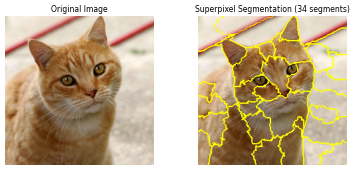

In [7]:
segments = quickshift(img_np, kernel_size=4, max_dist=200, ratio=0.2)
unique_segs = np.unique(segments)
n_segs = len(unique_segs)
print(f"Number of superpixels: {n_segs}")

plt.figure(figsize=(8, 3.5))

plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Original Image", fontsize=11)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(img_np, segments))
plt.title(f"Superpixel Segmentation ({n_segs} segments)", fontsize=11)
plt.axis("off")

plt.tight_layout()
plt.show()

Running LIME (1000 samples)...


  0%|          | 0/1000 [00:00<?, ?it/s]

LIME done in 12.7s


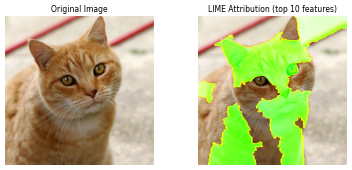


LIME's top 10 superpixels:
  Segment  11: +0.1269
  Segment  25: +0.1151
  Segment   7: +0.1084
  Segment  31: +0.0745
  Segment  12: +0.0707
  Segment  29: +0.0502
  Segment   8: +0.0434
  Segment   6: +0.0420
  Segment   1: +0.0402
  Segment  16: +0.0387


In [8]:
print("Running LIME (1000 samples)...")
t0 = time.time()

explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    img_np,
    predict_probs,
    top_labels=1,
    hide_color=None,
    num_samples=1000,
    random_seed=42
)

print(f"LIME done in {time.time() - t0:.1f}s")

temp, mask = explanation.get_image_and_mask(
    class_idx, positive_only=False, num_features=10, hide_rest=False
)

plt.figure(figsize=(8, 3.5))

plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Original Image", fontsize=11)
plt.axis("off")

plt.subplot(1, 2, 2)
disp = temp / 255.0 if temp.max() > 1 else temp
plt.imshow(mark_boundaries(disp, mask))
plt.title("LIME Attribution (top 10 features)", fontsize=11)
plt.axis("off")

plt.tight_layout()
plt.show()

local_exp = explanation.local_exp[class_idx]
print("\nLIME's top 10 superpixels:")
for seg_id, score in sorted(local_exp, key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"  Segment {seg_id:3d}: {score:+.4f}")

In [9]:
print("Computing pairwise interactions...")
n = len(unique_segs)
total_pairs = n * (n - 1) // 2
print(f"Superpixels: {n}, Pairs: {total_pairs}")

orig_conf = get_confidence(img_np, class_idx)
print(f"Original confidence: {orig_conf:.4f}")

individual_drops = {}
for seg_id in tqdm(unique_segs, desc="Individual drops"):
    perturbed = hide_superpixels(img_np, segments, [seg_id])
    conf = get_confidence(perturbed, class_idx)
    individual_drops[seg_id] = orig_conf - conf

interaction_matrix = np.zeros((n, n))
pairs = list(combinations(range(n), 2))

for idx_i, idx_j in tqdm(pairs, desc="Pairwise drops"):
    seg_i = unique_segs[idx_i]
    seg_j = unique_segs[idx_j]
    perturbed = hide_superpixels(img_np, segments, [seg_i, seg_j])
    conf = get_confidence(perturbed, class_idx)
    delta_ij = orig_conf - conf
    interaction = delta_ij - individual_drops[seg_i] - individual_drops[seg_j]
    interaction_matrix[idx_i, idx_j] = interaction
    interaction_matrix[idx_j, idx_i] = interaction

individual_array = np.array([individual_drops[s] for s in unique_segs])
print("Done.")

Computing pairwise interactions...
Superpixels: 34, Pairs: 561
Original confidence: 0.6926


Individual drops:   0%|          | 0/34 [00:00<?, ?it/s]

Pairwise drops:   0%|          | 0/561 [00:00<?, ?it/s]

Done.


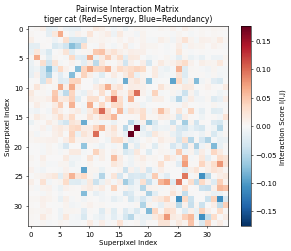


Interaction Statistics:
  Total pairs: 561
  Mean |interaction|: 0.015095
  Max synergy (positive): 0.176217
  Max redundancy (negative): -0.107485
  Std of interactions: 0.024655
  Significant pairs (|I|>0.01): 43.0%
  Synergistic (I>0.01): 24.6%
  Redundant (I<-0.01): 18.4%


In [10]:
fig, ax = plt.subplots(figsize=(6, 5))

max_val = max(abs(interaction_matrix.min()), abs(interaction_matrix.max()), 1e-6)
im = ax.imshow(interaction_matrix, cmap="RdBu_r", vmin=-max_val, vmax=max_val)

ax.set_xlabel("Superpixel Index", fontsize=10)
ax.set_ylabel("Superpixel Index", fontsize=10)
ax.set_title(f"Pairwise Interaction Matrix\n{class_name} (Red=Synergy, Blue=Redundancy)", fontsize=11)
plt.colorbar(im, ax=ax, label="Interaction Score I(i,j)")

plt.tight_layout()
plt.show()

upper_tri = interaction_matrix[np.triu_indices(n, k=1)]
print(f"\nInteraction Statistics:")
print(f"  Total pairs: {len(upper_tri)}")
print(f"  Mean |interaction|: {np.mean(np.abs(upper_tri)):.6f}")
print(f"  Max synergy (positive): {np.max(upper_tri):.6f}")
print(f"  Max redundancy (negative): {np.min(upper_tri):.6f}")
print(f"  Std of interactions: {np.std(upper_tri):.6f}")
print(f"  Significant pairs (|I|>0.01): {np.mean(np.abs(upper_tri) > 0.01)*100:.1f}%")
print(f"  Synergistic (I>0.01): {np.mean(upper_tri > 0.01)*100:.1f}%")
print(f"  Redundant (I<-0.01): {np.mean(upper_tri < -0.01)*100:.1f}%")

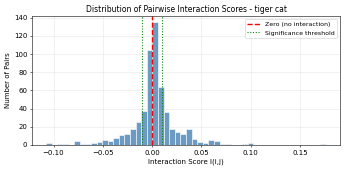

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.5))

ax.hist(upper_tri, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Zero (no interaction)")
ax.axvline(x=0.01, color="green", linestyle=":", linewidth=1.5, label="Significance threshold")
ax.axvline(x=-0.01, color="green", linestyle=":", linewidth=1.5)

ax.set_xlabel("Interaction Score I(i,j)", fontsize=10)
ax.set_ylabel("Number of Pairs", fontsize=10)
ax.set_title(f"Distribution of Pairwise Interaction Scores - {class_name}", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

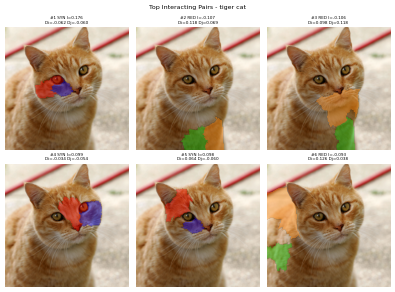

In [12]:
pair_indices = list(zip(*np.triu_indices(n, k=1)))
interaction_values = interaction_matrix[np.triu_indices(n, k=1)]
sorted_idx = np.argsort(np.abs(interaction_values))[::-1]

fig, axes = plt.subplots(2, 3, figsize=(8, 6))

for k in range(min(6, len(sorted_idx))):
    idx = sorted_idx[k]
    i, j = pair_indices[idx]
    val = interaction_values[idx]
    di = individual_array[i]
    dj = individual_array[j]

    row, col = k // 3, k % 3
    ax = axes[row, col]

    highlight = np.zeros((*segments.shape, 4))
    mask_i = segments == unique_segs[i]
    mask_j = segments == unique_segs[j]

    if val > 0:
        highlight[mask_i] = [1, 0, 0, 0.4]
        highlight[mask_j] = [0, 0, 1, 0.4]
        ptype = "SYN"
    else:
        highlight[mask_i] = [1, 0.5, 0, 0.4]
        highlight[mask_j] = [0, 0.8, 0, 0.4]
        ptype = "RED"

    ax.imshow(img_np)
    ax.imshow(highlight)
    ax.set_title(
        f"#{k+1} {ptype} I={val:.3f}\n"
        f"Di={di:.3f} Dj={dj:.3f}",
        fontsize=6
    )
    ax.axis("off")

plt.suptitle(f"Top Interacting Pairs - {class_name}", fontsize=9)
plt.tight_layout()
plt.show()

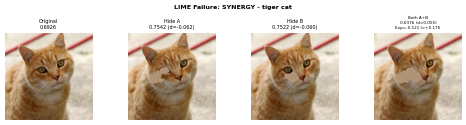

LIME assumes joint drop = -0.1213 (= -0.0616 + -0.0597)
Actual joint drop = 0.0549
Interaction I(A,B) = +0.1762 (SYNERGY)


In [13]:
top_idx = sorted_idx[0]
i, j = pair_indices[top_idx]
val = interaction_values[top_idx]
di = individual_array[i]
dj = individual_array[j]

fig, axes = plt.subplots(1, 4, figsize=(10, 2.5))

axes[0].imshow(img_np)
axes[0].set_title(f"Original\n{orig_conf:.4f}", fontsize=7)
axes[0].axis("off")

perturbed_i = hide_superpixels(img_np, segments, [unique_segs[i]])
conf_i = get_confidence(perturbed_i, class_idx)
axes[1].imshow(perturbed_i)
axes[1].set_title(f"Hide A\n{conf_i:.4f} (d={di:.3f})", fontsize=7)
axes[1].axis("off")

perturbed_j = hide_superpixels(img_np, segments, [unique_segs[j]])
conf_j = get_confidence(perturbed_j, class_idx)
axes[2].imshow(perturbed_j)
axes[2].set_title(f"Hide B\n{conf_j:.4f} (d={dj:.3f})", fontsize=7)
axes[2].axis("off")

perturbed_both = hide_superpixels(img_np, segments, [unique_segs[i], unique_segs[j]])
conf_both = get_confidence(perturbed_both, class_idx)
delta_both = orig_conf - conf_both
expected = di + dj
axes[3].imshow(perturbed_both)
axes[3].set_title(
    f"Both A+B\n{conf_both:.4f} (d={delta_both:.3f})\n"
    f"Exp={expected:.3f} I={val:+.3f}",
    fontsize=6
)
axes[3].axis("off")

interaction_type = "SYNERGY" if val > 0 else "REDUNDANCY"
plt.suptitle(f"LIME Failure: {interaction_type} - {class_name}", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"LIME assumes joint drop = {expected:.4f} (= {di:.4f} + {dj:.4f})")
print(f"Actual joint drop = {delta_both:.4f}")
print(f"Interaction I(A,B) = {val:+.4f} ({interaction_type})")

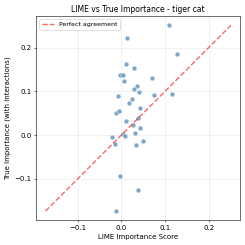

Spearman correlation: ρ = 0.3018 (p = 0.0828)
Sign agreement: 76.5%


In [14]:
local_exp = explanation.local_exp[class_idx]
lime_dict = {seg: score for seg, score in local_exp}
lime_scores = np.array([lime_dict.get(unique_segs[i], 0.0) for i in range(n)])

true_importance = individual_array.copy()
for i in range(n):
    true_importance[i] += np.sum(interaction_matrix[i]) / 2

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(lime_scores, true_importance, alpha=0.7, s=50, c="steelblue", edgecolors="white")
ax.set_xlabel("LIME Importance Score", fontsize=10)
ax.set_ylabel("True Importance (with interactions)", fontsize=10)
ax.set_title(f"LIME vs True Importance - {class_name}", fontsize=11)

mn = min(lime_scores.min(), true_importance.min())
mx = max(lime_scores.max(), true_importance.max())
ax.plot([mn, mx], [mn, mx], "r--", alpha=0.6, linewidth=2, label="Perfect agreement")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

from scipy.stats import spearmanr
rho, pval = spearmanr(lime_scores, true_importance)
sign_agree = np.mean(np.sign(lime_scores) == np.sign(true_importance))
print(f"Spearman correlation: ρ = {rho:.4f} (p = {pval:.4f})")
print(f"Sign agreement: {sign_agree:.1%}")

## Key Findings

- **29–43%** of superpixel pairs show significant interactions ($|I| > 0.01$)
- Interaction magnitudes reach up to **0.56**, comparable to initial model confidence
- LIME produces **magnitude errors**, **sign reversals**, and **rank distortions** due to unmodeled interactions
- These findings motivate the interaction-aware methods in Notebook 2